##### Time series prediction using XGBoost for demand data (2008 - 2018)

* Training - 2008 to 2017
* Testing - 2018

In [ ]:
!pip install xgboost statsmodels

In [ ]:
!pip install prophet openpyxl

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb
from sklearn.metrics import mean_squared_error
from datetime import datetime
from prophet import Prophet

color_pal = sns.color_palette()

In [ ]:
# Override the default linewidth and markersize
plt.rcParams['lines.linewidth'] = 1
plt.rcParams['lines.markersize'] = 5

In [ ]:
# Import dataset
df = pd.read_csv('2008_2018_demand.csv')
df = df.set_index('Date')
df.index = pd.to_datetime(df.index, format = '%m/%d/%y %H:%M')

**Side Note:**

---



**In order to represent a small geographical area having its own distribution network within New South Wales; we assume that the total demand at every time period at this location is 0.05% the total electricity demand in New South Wales, Australia.**

In [ ]:
# Resample data to hourly intervals
df_hourly = df.resample('H').mean(numeric_only = True)

df_hourly['Demand'] = df_hourly['Demand'] * 0.0005

df_hourly

,Demand
Date,
2008-01-01 00:00:00,3.883800
2008-01-01 01:00:00,3.664215
2008-01-01 02:00:00,3.331627
2008-01-01 03:00:00,3.151432
2008-01-01 04:00:00,3.061030
...,...
2018-12-31 19:00:00,4.304050
2018-12-31 20:00:00,4.130763
2018-12-31 21:00:00,4.049410


In [ ]:
# Define target test cutoff date

TARGET_TEST_CUTOFF_DATE = '2017-12-31 23:00:00'

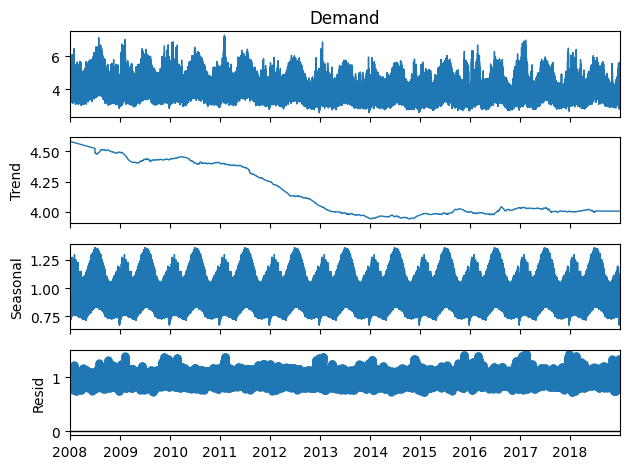

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

ANNUAL_PERIOD = 365*24
mult_decomp = seasonal_decompose(df_hourly['Demand'], model = 'multiplicative', extrapolate_trend = 'freq', period = ANNUAL_PERIOD)
mult_decomp.plot()
plt.show()

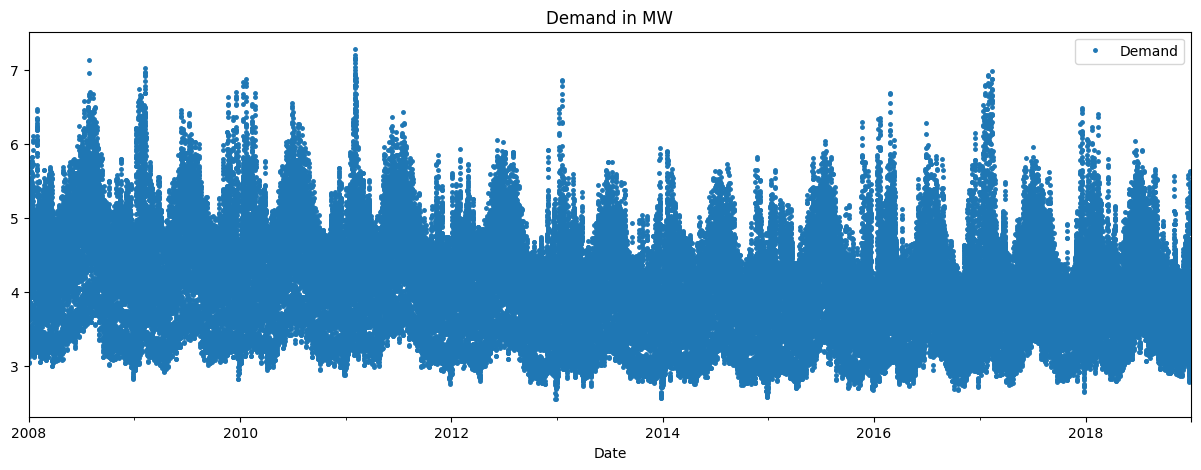

In [ ]:
df_hourly.plot(style = '.',
               figsize = (15, 5),
               color = color_pal[0],
               title = 'Demand in MW')

plt.show()

In [ ]:
train = df_hourly.loc[df_hourly.index <= TARGET_TEST_CUTOFF_DATE]
test = df_hourly.loc[df_hourly.index > TARGET_TEST_CUTOFF_DATE]

In [ ]:
# Function for plotting train-test splits

def plot_train_test_split(df: pd.DataFrame, split_date: str) -> None:
  """
  Plots the train/test split of the input DataFrame.

  Args:
    df (pd.DataFrame): Input DataFrame with a DatetimeIndex
    split_date(str): Date in the format 'YYYY-MM-DD H:M:S' to split the DataFrame.

  Returns:
    None
  """

  train = df.loc[df.index <= split_date]
  test = df.loc[df.index > split_date]

  fig, ax = plt.subplots(figsize = (15, 5))
  train.plot(ax = ax, label = 'Training Set', title = 'Data Train/Test Split', linewidth = 1, markersize = 5)
  test.plot(ax = ax, label = 'Test Set', linewidth = 1, markersize = 5)
  ax.axvline(pd.Timestamp(split_date), color = 'black', ls = '--')
  ax.legend(['Training Set', 'Test Set'])
  plt.show()

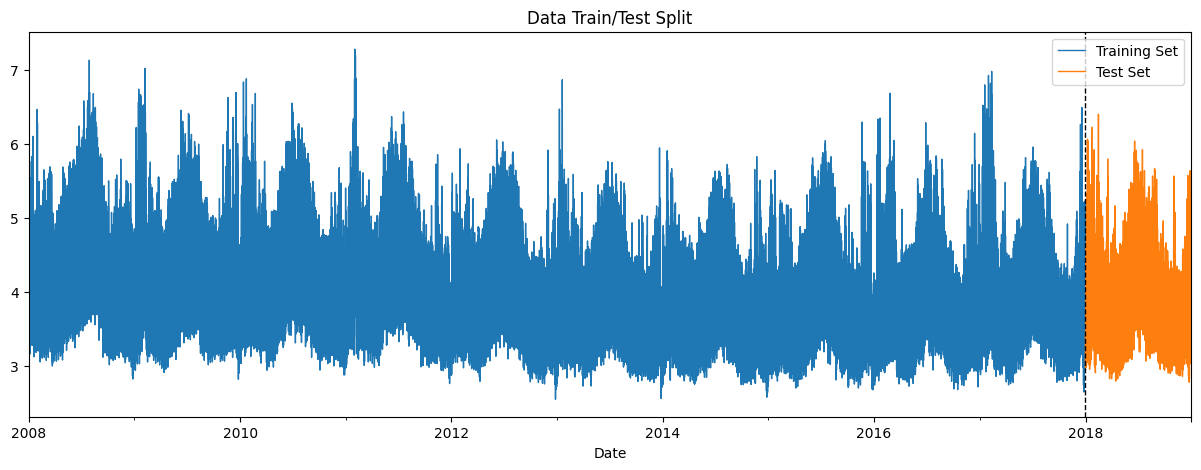

In [ ]:
plot_train_test_split(df_hourly, TARGET_TEST_CUTOFF_DATE)

In [ ]:
# Function for plotting between two date ranges. To see how a single weekly data looks like

def plot_week_of_data(df: pd.DataFrame, start_date: str, end_date: str) -> None:
  """
  Plot a week of data from the input DataFrame within a specified date range.

  Args:
    df (pd.DataFrame): Input DataFrame with a DatetimeIndex
    start_date(str): Start date in the format 'YYYY-MM-DD H:M:S'
    end_date(str): End date in the format 'YYYY-MM-DD H:M:S'

  Returns:
    None
  """
  df.loc[(df.index > start_date) & (df.index < end_date)].plot(figsize = (15, 5), \
                                    title = 'Week of Data', linewidth = 1, markersize = 5)

  plt.show()

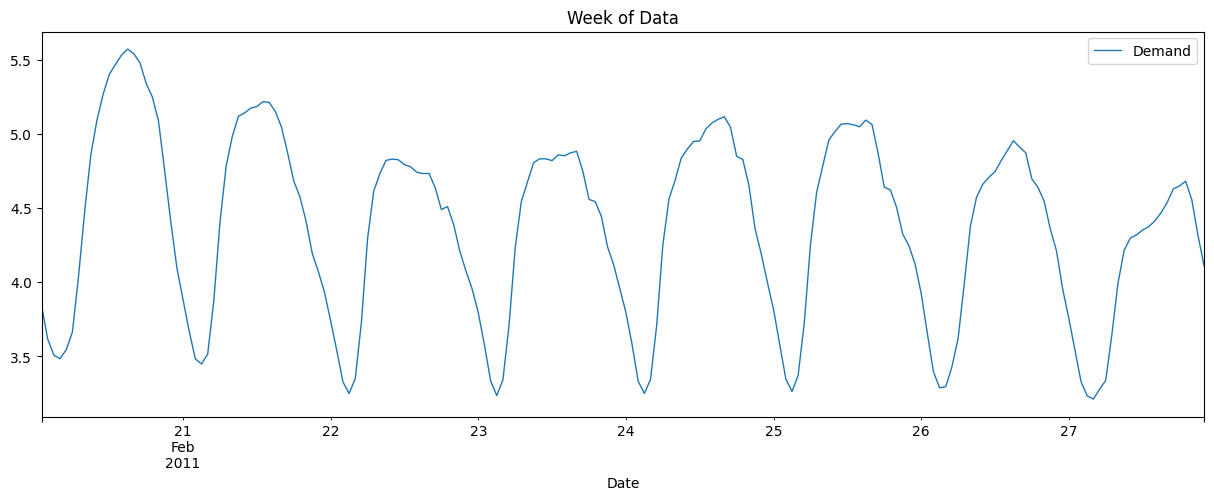

In [ ]:
plot_week_of_data(df_hourly, '2011-02-20 00:00:00', '2011-02-27 23:00:00')

In [ ]:
# Feature Engineeering for Time Series

def create_time_series_features(df: pd.DataFrame) -> pd.DataFrame:
  """
  From Date column of the original dataframe create features for the time series

  Args:
    df (pd.DataFrame): Input DataFrame with a Datetime Index

  Returns:
    pd.DataFrame: DataFrame with additional time series features

  Raises:
    ValueError: If input DataFrame does not have a Datetime Index.
  """

  if not isinstance(df.index, pd.DatetimeIndex):
    raise ValueError("Input DataFrame must have a Datetime Index.")

  df = df.copy()

  features = {
      'hour': df.index.hour,
      'dayofweek': df.index.dayofweek,
      'quarter': df.index.quarter,
      'month': df.index.month,
      'year': df.index.year,
      'dayofyear': df.index.dayofyear,
      'dayofmonth': df.index.day,
      'weekofyear': df.index.isocalendar().week
  }

  for feature_name, feature_values in features.items():
    df[feature_name] = feature_values

  return df

In [ ]:
hourly_df = create_time_series_features(df_hourly)

##### Creating our Model

In [ ]:
train.head()

,Demand
Date,
2008-01-01 00:00:00,3.883800
2008-01-01 01:00:00,3.664215
2008-01-01 02:00:00,3.331627
2008-01-01 03:00:00,3.151432
2008-01-01 04:00:00,3.061030


In [ ]:
test.head()

,Demand
Date,
2018-01-01 00:00:00,3.456125
2018-01-01 01:00:00,3.302923
2018-01-01 02:00:00,3.114278
2018-01-01 03:00:00,3.020728
2018-01-01 04:00:00,2.980563


In [ ]:
train = create_time_series_features(train)
test = create_time_series_features(test)

In [ ]:
train['weekofyear'] = train['weekofyear'].astype('int32')
test['weekofyear'] = test['weekofyear'].astype('int32')

In [ ]:
# Defining the train and test features & target for the TS

time_series_features = ['dayofyear', 'hour', 'dayofweek', 'weekofyear', 'quarter', 'month', 'year']

time_series_target = 'Demand'

X_train = train[time_series_features]
y_train = train[time_series_target]

X_test = test[time_series_features]
y_test = test[time_series_target]

In [ ]:
# XGBoost regressor function code

def train_xgb_regressor(X_train, y_train, X_test, y_test, use_gpu = False):
  """
  Train an XGBoost Regressor model using the provided training and test data

  Args:
    X_train: Training feature set.
    y_train: Training target set.
    X_test: Test feature set.
    y_test: Test target set.
    use_gpu (bool): Whether to use GPU for training. Default is False.

  Returns:
    xgb.XGBRegressor: Trained XGBoost Regressor model.
  """

  additional_params = {}
  if use_gpu:
    additional_params = {'tree_method': 'gpu_hist', 'gpu_id': 0}

  xgb_regressor = xgb.XGBRegressor(base_score = 0.5, booster = 'gbtree',
                                   n_estimators = 3000,
                                   early_stopping_rounds = 50,
                                   objective = 'reg:linear',
                                   max_depth = 6,
                                   learning_rate = 0.01,
                                   min_child_weight = 1,
                                   subsample = 0.8,
                                   colsample_bytree = 0.8,
                                   gamma = 0,
                                   reg_alpha = 0,
                                   reg_lambda = 1,
                                   **additional_params)
  xgb_regressor.fit(X_train, y_train,
                    eval_set = [(X_train, y_train), (X_test, y_test)],
                    verbose = 100)

  return xgb_regressor

In [ ]:
model = train_xgb_regressor(X_train, y_train, X_test, y_test, use_gpu = False)

[0]	validation_0-rmse:3.70188	validation_1-rmse:3.51410


/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [13:17:57] WARNING: /workspace/src/objective/regression_obj.cu:227: reg:linear is now deprecated in favor of reg:squarederror.
  warnings.warn(smsg, UserWarning)


[100]	validation_0-rmse:1.39785	validation_1-rmse:1.30098
[200]	validation_0-rmse:0.57976	validation_1-rmse:0.54904
[300]	validation_0-rmse:0.32458	validation_1-rmse:0.34665
[400]	validation_0-rmse:0.25916	validation_1-rmse:0.31121
[500]	validation_0-rmse:0.23742	validation_1-rmse:0.30392
[600]	validation_0-rmse:0.22626	validation_1-rmse:0.30256
[615]	validation_0-rmse:0.22495	validation_1-rmse:0.30275


##### Do a feature importance plot

In [ ]:
# Plot feature importance

def plot_feature_importance(model):
  """
  Plot the feature importance of a trained XGBoost model

  Args:
    model (xgb.XGBRegressor): Trained XGBoost Regressor model.

  Returns:
    None
  """
  feat_importances = pd.DataFrame(data = model.feature_importances_,
                                  index = model.feature_names_in_,
                                  columns = ['importance'])
  feat_importances.sort_values('importance').plot(kind = 'barh', title = 'Feature Importance (Demand, MW)')

  plt.show()

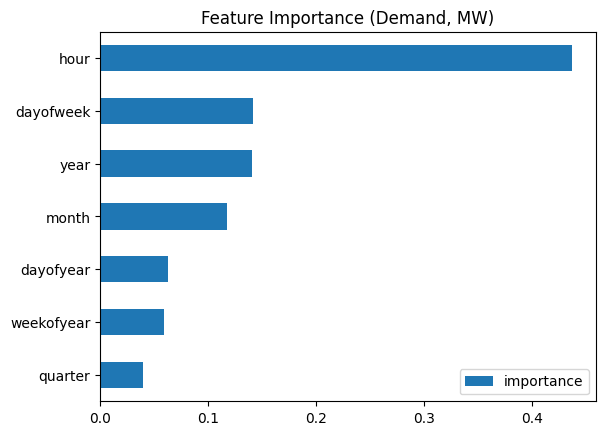

In [ ]:
plot_feature_importance(model)

##### Inference on Test

In [ ]:
test['prediction'] = model.predict(X_test)

hourly_df = hourly_df.merge(test[['prediction']], how = 'left', left_index = True, \
                            right_index = True)

In [ ]:
hourly_df.tail()

,Demand,hour,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear,prediction
Date,,,,,,,,,,
2018-12-31 19:00:00,4.304050,19,0,4,12,2018,365,31,1,4.036401
2018-12-31 20:00:00,4.130763,20,0,4,12,2018,365,31,1,3.948638
2018-12-31 21:00:00,4.049410,21,0,4,12,2018,365,31,1,3.763351
2018-12-31 22:00:00,4.024413,22,0,4,12,2018,365,31,1,3.697961
2018-12-31 23:00:00,3.905542,23,0,4,12,2018,365,31,1,3.586328


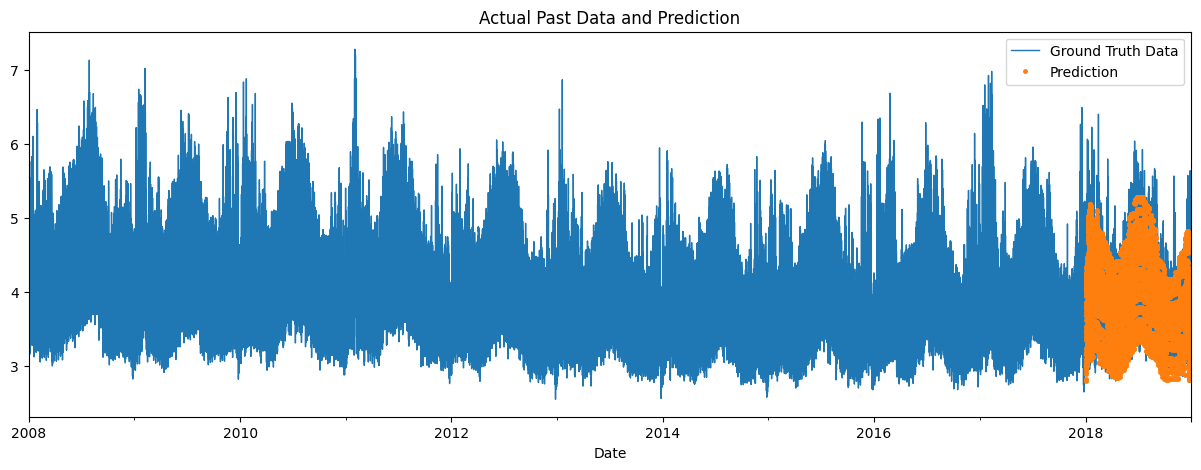

In [ ]:
# Visualizing prediction against ground truth data

ax = hourly_df[['Demand']].plot(figsize = (15, 5))

hourly_df['prediction'].plot(ax = ax, style = '.')

plt.legend(['Ground Truth Data', 'Prediction'])
ax.set_title('Actual Past Data and Prediction')

plt.show()

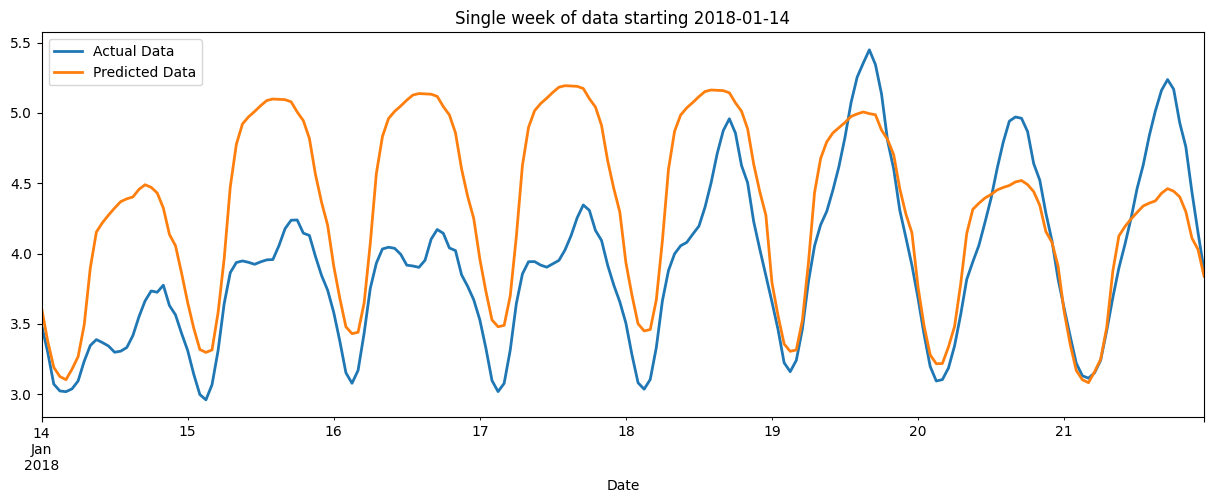

In [ ]:
# Select Data within a certain date range

data = hourly_df.loc['2018-01-14':'2018-01-21']

# Plot the actual and predicted data
ax = data['Demand'].plot(figsize = (15, 5), title = 'Single week of data starting 2018-01-14', linewidth = 2, markersize = 5)

data['prediction'].plot(style = '-', linewidth = 2, markersize = 5)

plt.legend(['Actual Data', 'Predicted Data'])

plt.show()

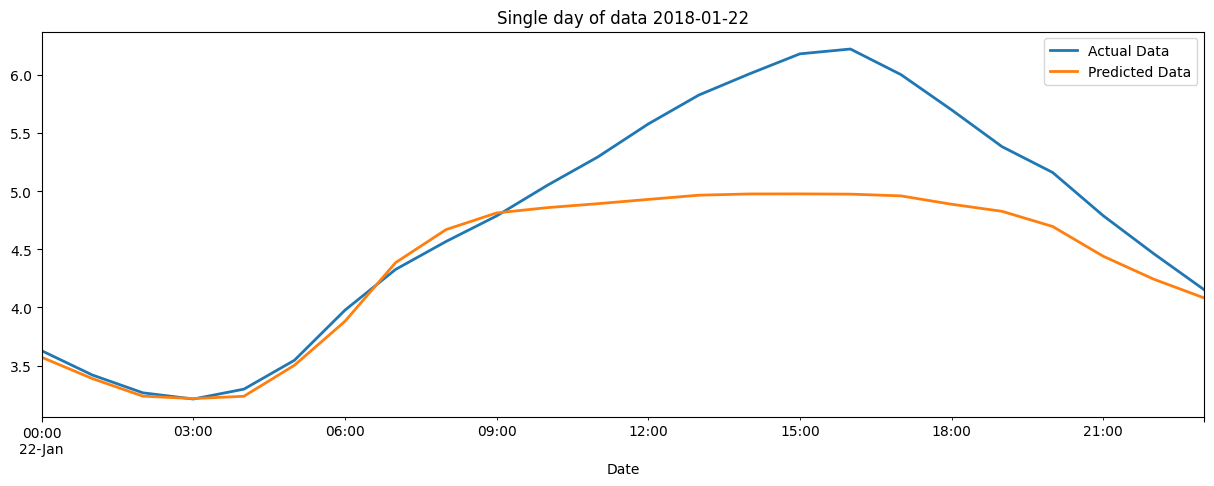

In [ ]:
# Select data for all hours in a single day
data_one_day = hourly_df.loc['2018-01-22':'2018-01-22']

# Plot the actual and predicted data
ax = data_one_day['Demand'].plot(figsize = (15, 5), title = 'Single day of data 2018-01-22', linewidth = 2, markersize = 5)

data_one_day['prediction'].plot(style = '-', linewidth = 2, markersize = 5)

plt.legend(['Actual Data', 'Predicted Data'])

plt.show()

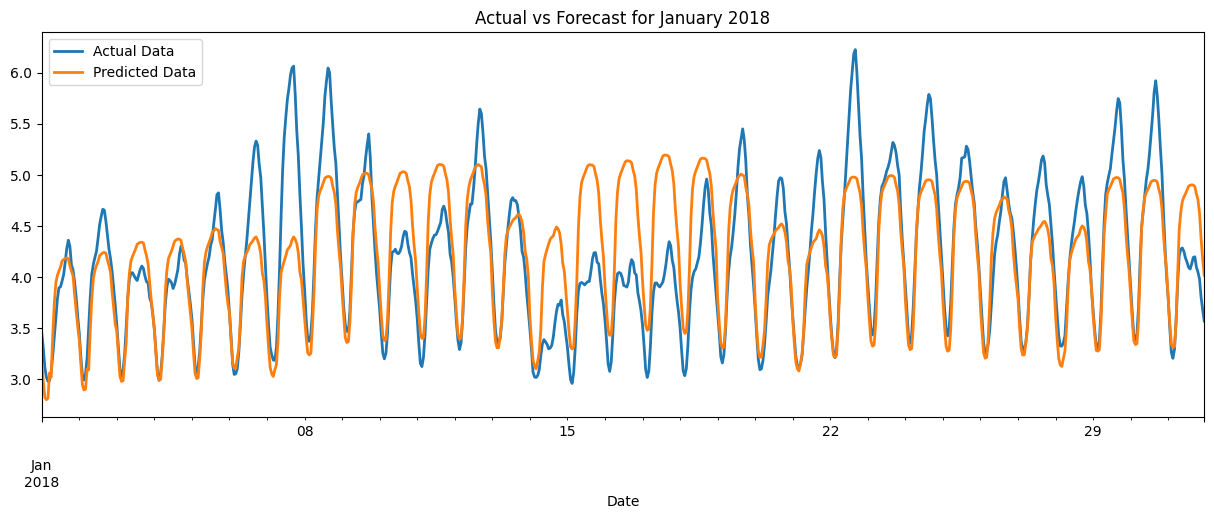

In [ ]:
# For the whole of January

# Select data for the month of January

data_month = hourly_df.loc['2018-01-01':'2018-01-31']

# Plot the actual and predicted data
ax = data_month['Demand'].plot(figsize = (15, 5), title = 'Actual vs Forecast for January 2018', linewidth = 2, markersize = 5)

data_month['prediction'].plot(style = '-', linewidth = 2, markersize = 5)

plt.legend(['Actual Data', 'Predicted Data'])

plt.show()

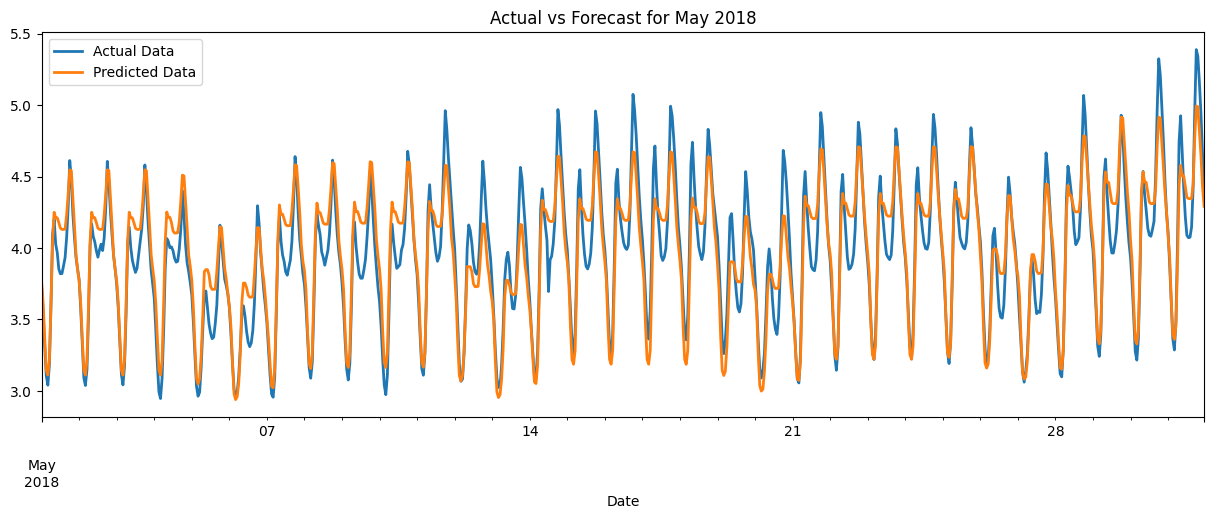

In [ ]:
# For the whole of May

# Select data for the month of May

data_month = hourly_df.loc['2018-05-01':'2018-05-31']

# Plot the actual and predicted data
ax = data_month['Demand'].plot(figsize = (15, 5), title = 'Actual vs Forecast for May 2018', linewidth = 2, markersize = 5)

data_month['prediction'].plot(style = '-', linewidth = 2, markersize = 5)

plt.legend(['Actual Data', 'Predicted Data'])

plt.show()

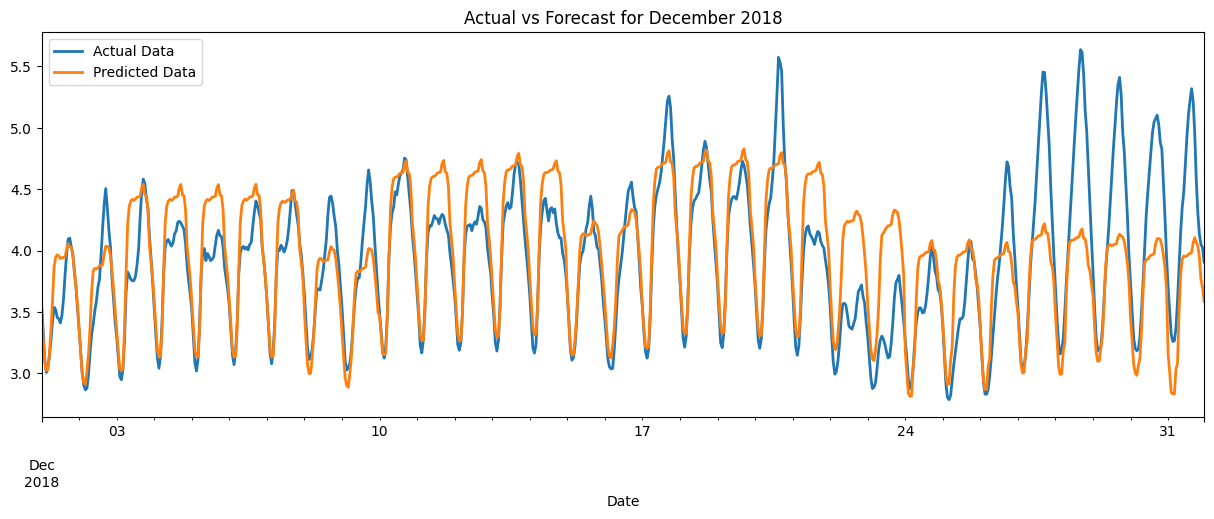

In [ ]:
# For the whole of December

# Select data for the month of December

data_month = hourly_df.loc['2018-12-01':'2018-12-31']

# Plot the actual and predicted data
ax = data_month['Demand'].plot(figsize = (15, 5), title = 'Actual vs Forecast for December 2018', linewidth = 2, markersize = 5)

data_month['prediction'].plot(style = '-', linewidth = 2, markersize = 5)

plt.legend(['Actual Data', 'Predicted Data'])

plt.show()

##### RMSE

In [ ]:
score = np.sqrt(mean_squared_error(test['Demand'], test['prediction']))

print(f'RMSE Score on Test set: {score: 0.2f}')

RMSE Score on Test set:  0.30


In [ ]:
# Compute the error of each forecast

test['error_demand'] = np.abs(test['Demand'] - test['prediction'])

In [ ]:
# Compute the error of each forecast

test['error_demand_raw'] = test['Demand'] - test['prediction']

In [ ]:
test.head()

,Demand,hour,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear,prediction,error_demand,error_demand_raw
Date,,,,,,,,,,,,
2018-01-01 00:00:00,3.456125,0,0,1,1,2018,1,1,1,3.166106,0.290019,0.290019
2018-01-01 01:00:00,3.302923,1,0,1,1,2018,1,1,1,2.982997,0.319925,0.319925
2018-01-01 02:00:00,3.114278,2,0,1,1,2018,1,1,1,2.822440,0.291838,0.291838
2018-01-01 03:00:00,3.020728,3,0,1,1,2018,1,1,1,2.801310,0.219418,0.219418
2018-01-01 04:00:00,2.980563,4,0,1,1,2018,1,1,1,2.814950,0.165613,0.165613


In [ ]:
# Save the error in load demand (MW) for predicted year 2014

pred_2018_data = test[['error_demand']]

import pickle

with open('error_demand_2018.pickle', 'wb') as file:
  pickle.dump(pred_2018_data, file)